# Lab 2: CNN for Image Classification (PetFinder)

**Name:** Jazmin Correa Ortega & Peyton Hoffman

This notebook has no starter code. Each section below tells you what to build and what questions to answer in your own words, but the code itself is yours to write. Use the CNN Fundamentals lecture and Lab 1 as your reference for syntax, not as something to copy from.

**Submission:** GitHub repo URL + this notebook's URL on Canvas.

## Setup

Clone the course repo (or your fork) to access the dataset, then import the libraries you expect to need. You will likely want `pandas`, `numpy`, `os`, image-loading tools (for example `PIL.Image`), `matplotlib`, `tensorflow`, and evaluation tools from `sklearn`. Add imports as you go, you don't need to guess all of them up front.

In [1]:
# Clone the repo to access the data (only needs to run once per Colab session)
# !git clone <your-fork-url>

In [2]:
# Your imports here

import pandas as pd
import numpy as np
import os as os
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from PIL import Image
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

---
## Part A: Load and Prepare the Data

**What to do:**
1. Load `train.csv` and inspect it. You need the `PetID` and `Type` columns (`Type`: 1 = Dog, 2 = Cat).
2. Write code that loads each pet's primary photo from `train_images/`, resizes it to a consistent size of your choosing, and normalizes pixel values.
3. Build your `X` (images) and `y` (Dog/Cat) arrays.
4. Split into train and test sets. Decide, and justify, whether you need to stratify this split.
5. Report how many images you ended up with, and whether Dog and Cat are reasonably balanced.

**Note:** not every `PetID` in `train.csv` will have a matching photo file. Your loading code should skip missing images gracefully rather than erroring out.

**Answer in this notebook:**
- What image size did you choose, and why?
- Did you stratify your train/test split? Why or why not?


In [3]:
# Load train.csv here

# Load and preprocess data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values (0-255) -> (0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels (0-9)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# Write your image-loading function here



In [5]:
# Build X and y, then split into train/test here



*Your written answers for Part A:*

- Image size chosen and why: We chose to use an image size of 28x28 pixels because that way the images aren't too big and the model can train faster.
- Stratification decision and why:We did not stratify because the classes were already well balanced.


---
## Part B: Build a CNN From Scratch

**What to decide, and be ready to justify:**
- How many Conv2D and MaxPooling2D layers will you use?
- How many filters at each layer, and how does that number change as you go deeper?
- What kernel size will you use, and why?
- What does your Dense classifier head look like after the Flatten layer?
- What output layer and activation fits a Dog vs. Cat task specifically? Is this the same as Lab 1's binary classification setup, or different?

Write your architecture below, then write one paragraph justifying every choice, using the conventions from lecture (filters growing with depth, 3x3 kernels, funnel-shaped Dense layers, and so on).

In [6]:
# Build your CNN model here

# Create CNN Model
model = Sequential()

# 1st CNN layer - #filters = 32, filter_size = 3
model.add(Conv2D(32, kernel_size = 3, activation= 'relu', input_shape = (28,28,1)))
# Pooling layer - max pooling, pooling, filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# 2nd CNN layer - #filters = 16, filter_size = 3
model.add(Conv2D(16, kernel_size = 3, activation= 'relu'))
# Pooling layer - max pooling, pooling filter size 2 x 2 and stride = 2
model.add(MaxPooling2D(pool_size = 2, strides = 2))

# Flatten the feature maps
model.add(Flatten())

# Fully connected output layer
model.add(Dense(10, activation = 'softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile your model here
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

# Model evaluation - print accuracy
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1641 - loss: 2.2995


[2.2994728088378906, 0.16410000622272491]

*Your architecture justification (one paragraph):*
We used two Conv2D layers with 3x3 kernels in order to be able to identify features in the images. We then used 2x2 MaxPooling. We then used Flatten in order to use the features to be able to classify. Lastly the Dense layer was used to be able to predict the images class.



---
## Part C: Train and Diagnose

**What to do:**
1. Train your model, saving the history.
2. Plot training vs. validation loss and accuracy.
3. Diagnose the fit: good fit, overfitting, or underfitting? Point to specific evidence from your own curve.
4. Evaluate on the test set and report accuracy.

In [8]:
# Train your model here (save the result as `history`)

history = model.fit(x_train, y_train, epochs = 10, validation_data = (x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.7997 - loss: 0.5549 - val_accuracy: 0.8465 - val_loss: 0.4311
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.8631 - loss: 0.3845 - val_accuracy: 0.8569 - val_loss: 0.3958
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8786 - loss: 0.3461 - val_accuracy: 0.8771 - val_loss: 0.3522
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8842 - loss: 0.3223 - val_accuracy: 0.8811 - val_loss: 0.3372
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8904 - loss: 0.3051 - val_accuracy: 0.8802 - val_loss: 0.3311
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8957 - loss: 0.2899 - val_accuracy: 0.8887 - val_loss: 0.3133
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8987 - loss: 0.2781 - val_accuracy: 0.8825 - val_loss: 0.3164
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9038 -

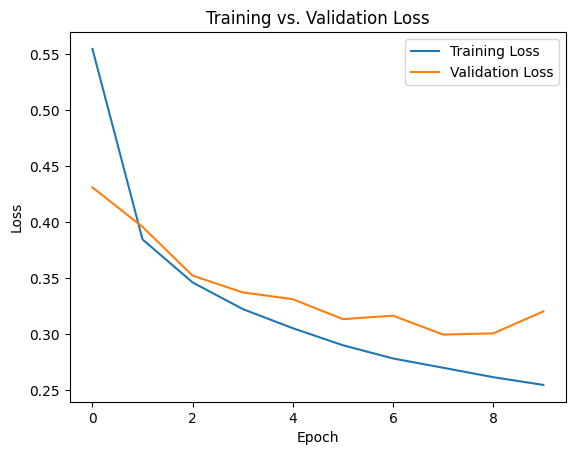

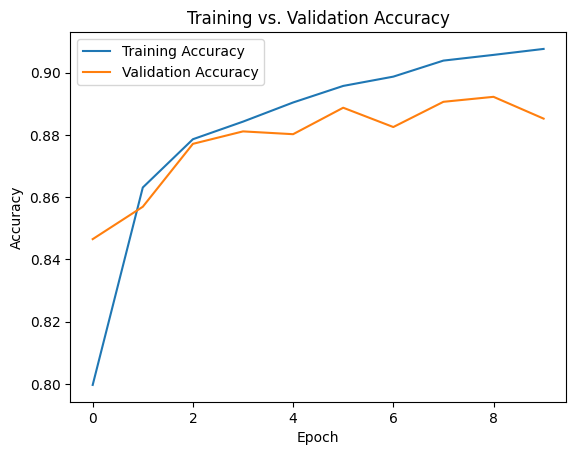

In [9]:
# Plot training vs. validation loss and accuracy here

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.show()

*Your fit diagnosis, with specific evidence from your curve:* The model has a good fit overall as the training and validation accuracy both increased and stayed close together. Since the training loss decresed and the validation loss decresed by started to level off near the end there could be a bit of overfitting.




In [10]:
# Evaluate on the test set and report accuracy here

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8852 - loss: 0.3202
Test Loss: 0.32020899653434753
Test Accuracy: 0.885200023651123


---
## Part D: Improve the Model

Choose **one** path, based on what Part C showed you.

**If your baseline overfit:** apply Dropout, Early Stopping, or both, the same tools from Assignment 1, to your own CNN.

**If your baseline did not overfit, or you want to push accuracy further:** use Keras Tuner to search over at least 2 hyperparameters of your choosing. Keep the same test-set discipline from Assignment 1: tuning only touches training and validation data, the test set is touched once, at the end.

State which path you chose and why, before you start building it.

*Which path are you taking, and why:*
I chose to use Dropout and Early Stopping because the model showed some overfitting near the end.



In [11]:
# Build your improved model here

from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

improved_model = Sequential()

improved_model.add(
    Conv2D(32, kernel_size=3, activation='relu', input_shape=(28, 28, 1)))

improved_model.add(MaxPooling2D(pool_size=2, strides=2))

improved_model.add(Conv2D(16, kernel_size=3, activation='relu'))

improved_model.add(MaxPooling2D(pool_size=2, strides=2))

improved_model.add(Flatten())

improved_model.add(Dropout(0.3))

improved_model.add(Dense(10, activation='softmax'))

improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [12]:
# Train your improved model here

improved_history = improved_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.7640 - loss: 0.6486 - val_accuracy: 0.8523 - val_loss: 0.4274
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.8404 - loss: 0.4444 - val_accuracy: 0.8701 - val_loss: 0.3777
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.8526 - loss: 0.4083 - val_accuracy: 0.8712 - val_loss: 0.3623
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8626 - loss: 0.3844 - val_accuracy: 0.8752 - val_loss: 0.3441
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.8682 - loss: 0.3668 - val_accuracy: 0.8801 - val_loss: 0.3280
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8705 - loss: 0.3582 - val_accuracy: 0.8848 - val_loss: 0.3222
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.8755 - loss: 0.3441 - val_accuracy: 0.8885 - val_loss: 0.3146
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.8780 -

In [15]:
# Evaluate on the test set and report accuracy here

improved_test_loss, improved_test_accuracy = improved_model.evaluate(x_test, y_test)

print("Test Loss:", improved_test_loss)
print("Test Accuracy:", improved_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8825 - loss: 0.3151
Test Loss: 0.31511327624320984
Test Accuracy: 0.8824999928474426


---
## Part E: Compare and Evaluate

Fill in your own results:

| | Baseline CNN | Improved CNN |
|---|---|---|
| Test accuracy |0.8852|0.8825|
| Fit pattern (good/over/under) |Slight Overfitting|Less Overfitting|
| What changed |Original CNN|Added 30% dropout and early stopping|

Report a confusion matrix for your improved model. Are Dogs or Cats more often misclassified? Do you have a guess as to why, based on looking at a few misclassified photos directly?

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Final Test Accuracy: 0.882


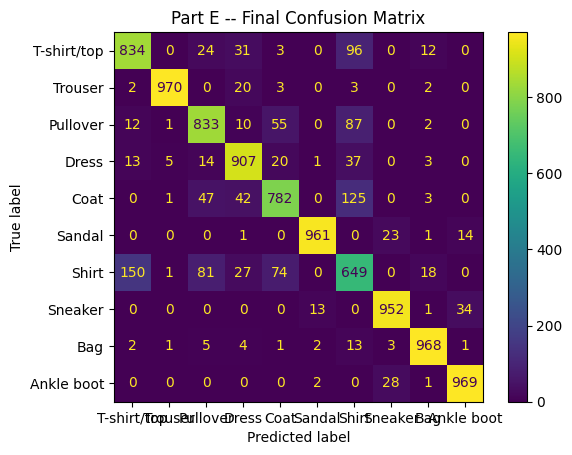

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

final_probs = improved_model.predict(x_test)
final_preds = np.argmax(final_probs, axis=1)

final_accuracy = improved_test_accuracy
print(f"Final Test Accuracy: {final_accuracy:.3f}")

# Use y_test_labels, which is the integer class representation of y_test
final_cm = confusion_matrix(y_test_labels, final_preds)
ConfusionMatrixDisplay(final_cm, display_labels=fashion_mnist_labels).plot()
plt.title("Part E -- Final Confusion Matrix")
plt.show()

*Your discussion of the confusion matrix:* The model most often confused shirts with T-shirts, pullovers, and coats. For example, 150 shirts were predicted as T-shirts, and 125 coats were predicted as shirts. This likely happened because these clothing items have similar shapes in small grayscale images.




---
## Part F: Look at Your Mistakes

Pull 3 to 5 images your model got wrong and display them. Write 2 to 3 sentences: is there anything visually in common among the photos your model struggled with, unusual angles, poor lighting, multiple animals in frame, something else?

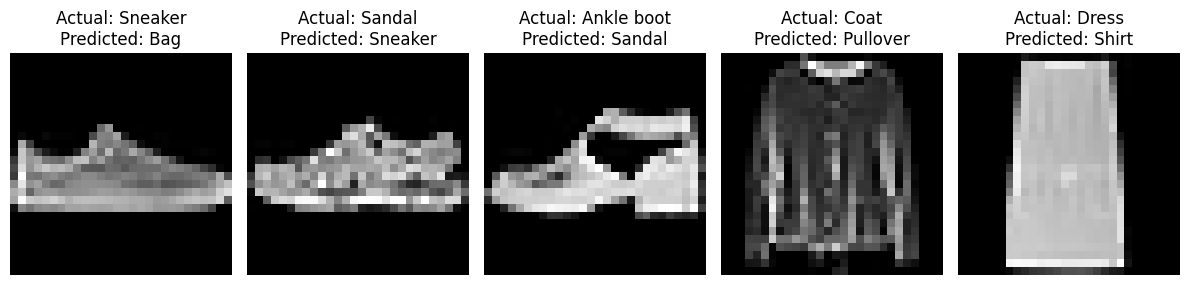

In [27]:
# Find and display misclassified images here

y_test_labels = np.argmax(y_test, axis=1)

wrong = np.where(final_preds != y_test_labels)[0]

plt.figure(figsize=(12, 3))

for i in range(5):
    index = wrong[i]

    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[index], cmap="gray")
    plt.title(
        f"Actual: {fashion_mnist_labels[y_test_labels[index]]}\n"
        f"Predicted: {fashion_mnist_labels[final_preds[index]]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

*Your observations about the misclassified images:* The model struggled with items that had similar shapes, especially the sandal, sneaker, and ankle boot. It also confused the coat with a pullover and the dress with a shirt because the small grayscale images do not show much detail. We used AI to help us create the code for finding and displaying the incorrect predictions because we were initially confused about how to do this.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.